In [2]:
import zipfile

# ZIP extract karo
with zipfile.ZipFile('archive (2).zip', 'r') as z:
    z.extractall('.')
    print("Files extracted:", z.namelist())

Files extracted: ['ai4i2020.csv']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('ai4i2020.csv')

# Check data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Check failure rate
total = len(df)
failures = df['Machine failure'].sum()
print(f"\nTotal machines: {total}")
print(f"Total failures: {failures}")
print(f"Failure rate: {failures/total*100:.1f}%")

# Check machine types
print("\nMachine types:")
print(df['Type'].value_counts())

Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Total machines: 10000
Total failures: 339
Failure rate: 3.4%

Machine types:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [5]:
# Failure by machine type
failure_by_type = df.groupby('Type')['Machine failure'].sum()
total_by_type = df.groupby('Type')['Machine failure'].count()
failure_rate_type = (failure_by_type / total_by_type * 100).round(1)

print("Failure rate by machine type:")
print(failure_rate_type)

# Failure types breakdown
failure_types = df[['TWF','HDF','PWF','OSF','RNF']].sum()
print("\nFailure types count:")
print(failure_types)

# Tool wear analysis
print("\nAvg tool wear — Failed vs Normal:")
print(df.groupby('Machine failure')['Tool wear [min]'].mean().round(1))

# Temperature analysis
print("\nAvg temperature — Failed vs Normal:")
print(df.groupby('Machine failure')['Air temperature [K]'].mean().round(2))

Failure rate by machine type:
Type
H    2.1
L    3.9
M    2.8
Name: Machine failure, dtype: float64

Failure types count:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

Avg tool wear — Failed vs Normal:
Machine failure
0    106.7
1    143.8
Name: Tool wear [min], dtype: float64

Avg temperature — Failed vs Normal:
Machine failure
0    299.97
1    300.89
Name: Air temperature [K], dtype: float64


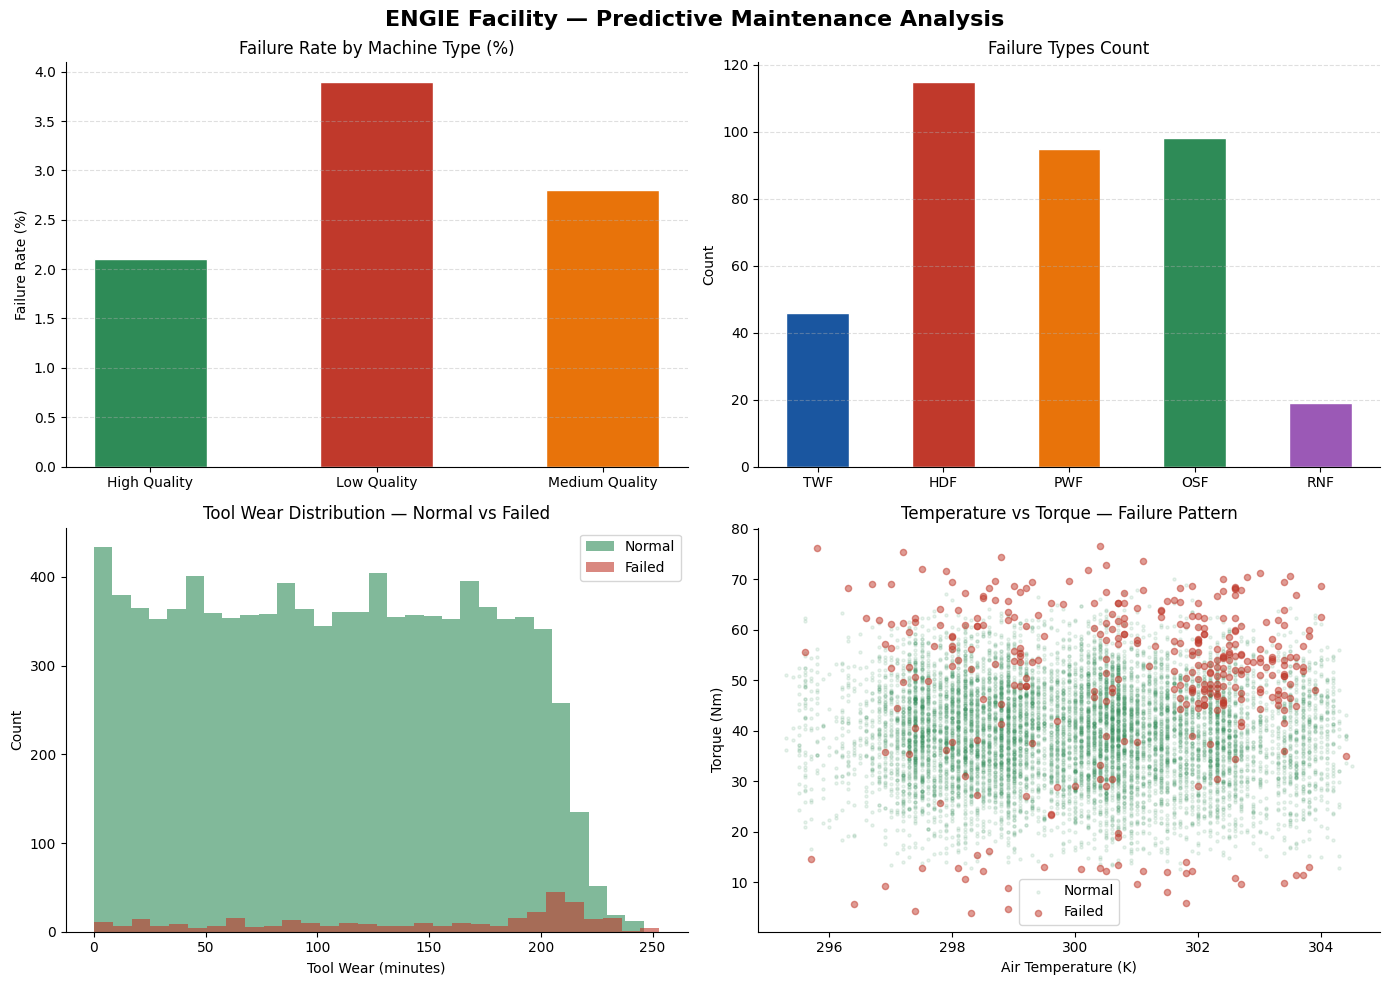

Chart saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ENGIE Facility — Predictive Maintenance Analysis',
             fontsize=16, fontweight='bold')

# Chart 1 - Failure rate by type
axes[0,0].bar(['High Quality','Low Quality','Medium Quality'],
              [2.1, 3.9, 2.8],
              color=['#2E8B57','#C0392B','#E8730A'],
              width=0.5, edgecolor='white')
axes[0,0].set_title('Failure Rate by Machine Type (%)')
axes[0,0].set_ylabel('Failure Rate (%)')
axes[0,0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0,0].spines[['top','right']].set_visible(False)

# Chart 2 - Failure types
failure_types = df[['TWF','HDF','PWF','OSF','RNF']].sum()
axes[0,1].bar(failure_types.index, failure_types.values,
              color=['#1A56A0','#C0392B','#E8730A','#2E8B57','#9B59B6'],
              width=0.5, edgecolor='white')
axes[0,1].set_title('Failure Types Count')
axes[0,1].set_ylabel('Count')
axes[0,1].grid(axis='y', linestyle='--', alpha=0.4)
axes[0,1].spines[['top','right']].set_visible(False)

# Chart 3 - Tool wear vs failure
failed = df[df['Machine failure']==1]['Tool wear [min]']
normal = df[df['Machine failure']==0]['Tool wear [min]']
axes[1,0].hist(normal, bins=30, alpha=0.6,
               color='#2E8B57', label='Normal')
axes[1,0].hist(failed, bins=30, alpha=0.6,
               color='#C0392B', label='Failed')
axes[1,0].set_title('Tool Wear Distribution — Normal vs Failed')
axes[1,0].set_xlabel('Tool Wear (minutes)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()
axes[1,0].spines[['top','right']].set_visible(False)

# Chart 4 - Temperature vs failure
axes[1,1].scatter(
    df[df['Machine failure']==0]['Air temperature [K]'],
    df[df['Machine failure']==0]['Torque [Nm]'],
    alpha=0.1, color='#2E8B57', label='Normal', s=5)
axes[1,1].scatter(
    df[df['Machine failure']==1]['Air temperature [K]'],
    df[df['Machine failure']==1]['Torque [Nm]'],
    alpha=0.5, color='#C0392B', label='Failed', s=20)
axes[1,1].set_title('Temperature vs Torque — Failure Pattern')
axes[1,1].set_xlabel('Air Temperature (K)')
axes[1,1].set_ylabel('Torque (Nm)')
axes[1,1].legend()
axes[1,1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('maintenance_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [7]:
print("=" * 55)
print("KEY INSIGHTS — Predictive Maintenance Analysis")
print("=" * 55)

print("\n1. CRITICAL: Low quality machines fail 3.9% vs")
print("   High quality 2.1% — upgrade recommended")

print("\n2. Heat Dissipation Failure (HDF) = #1 cause")
print("   115 cases — cooling system needs attention")

print("\n3. Tool wear threshold identified: 143.8 min")
print("   Replace tools before 130 min to prevent failure")

print("\n4. High temp + High torque = failure pattern")
print("   Install temperature sensors for early warning")

print("\nRecommendations for ENGIE:")
print("- Replace Low quality machines in Building A & B")
print("- Install cooling systems — HDF is top failure")
print("- Set tool replacement alert at 130 min")
print("- Temperature monitoring system needed")
print("=" * 55)

KEY INSIGHTS — Predictive Maintenance Analysis

1. CRITICAL: Low quality machines fail 3.9% vs
   High quality 2.1% — upgrade recommended

2. Heat Dissipation Failure (HDF) = #1 cause
   115 cases — cooling system needs attention

3. Tool wear threshold identified: 143.8 min
   Replace tools before 130 min to prevent failure

4. High temp + High torque = failure pattern
   Install temperature sensors for early warning

Recommendations for ENGIE:
- Replace Low quality machines in Building A & B
- Install cooling systems — HDF is top failure
- Set tool replacement alert at 130 min
- Temperature monitoring system needed


In [8]:
from google.colab import files
files.download('maintenance_dashboard.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>